In [ ]:
# checking the gpu access
!nvidia-smi

Sun Dec  5 19:08:10 2021       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 495.44       Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla K80           Off  | 00000000:00:04.0 Off |                    0 |
| N/A   49C    P0    57W / 149W |    540MiB / 11441MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
# !pip install livelossplot --quiet
# from livelossplot import PlotLosses

In [ ]:
# import the required modules
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.datasets import CIFAR10
from torch.utils.data import random_split, DataLoader
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
print(torch.__version__)

1.10.0+cu111


In [ ]:
# Fix the randomness
seed = 1234
torch.manual_seed(seed)

In [ ]:
# Download the dataset, and split it into Train, Val, and Test sets.
train_transform = T. Compose ([
T. ToTensor () , # convert images to PyTorch tensors
T. Grayscale () , # RGB to grayscale
T. Normalize ( mean =(0.5 ,) , std=(0.5 ,) ) # normalization speeds up the convergence and improves the accuracy
])

val_transform = test_transform = T. Compose ([
T. ToTensor () ,
T. Grayscale () ,
T. Normalize ( mean =(0.5 ,) , std=(0.5 ,) )
])

train_set = CIFAR10 ( root ='CIFAR10', train =True , transform = train_transform , download = True )
test_set = CIFAR10 ( root ='CIFAR10', train =False , transform = test_transform , download = True )

# hyperparameters: 0.6, 0.8, 0.95
# train_set_length = int(0.6 * len(train_set))
train_set_length = int(0.8 * len(train_set))
# train_set_length = int(0.95 * len(train_set))
val_set_length = len(train_set) - train_set_length

train_set, val_set = random_split(train_set, [train_set_length, val_set_length])

# Define the data loaders
batch_size = 32
train_loader = DataLoader(train_set, num_workers=2, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, num_workers=2, batch_size=batch_size)
test_loader = DataLoader(test_set, num_workers=2, batch_size=batch_size)

Files already downloaded and verified
Files already downloaded and verified


In [ ]:
# Define the ANN
class Model_1_layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=32*32, out_features=10)
    def forward(self, x):
          x = torch.flatten(x, 1)
          x = self.layer1(x)
          # not have to add softmax layer here
          return x

class Model_2_Layer(nn.Module):
    def __init__(self, num_layer1, function:str):
        super().__init__()
        self.layer1 = nn.Linear(in_features=32*32, out_features= num_layer1)
        self.layer2 = nn.Linear(in_features=num_layer1, out_features=10)
        self.function = function
    def forward(self,x):
        x = torch.flatten(x,1)
        if(self.function == "hardswish"):
            x = F.hardswish(self.layer1(x))
        elif(self.function == "relu"):
            x = F.relu(self.layer1(x))
        else:
            x = F.tanh(self.layer1(x))
        x = self.layer2(x)
        return x

class Model_3_Layer(nn.Module):
    def __init__(self, num_layer1, num_layer2, function:str):
        super().__init__()
        self.layer1 = nn.Linear(in_features=32*32, out_features= num_layer1)
        self.layer2 = nn.Linear(in_features=num_layer1, out_features=num_layer2)
        self.layer3 = nn.Linear(in_features=num_layer2, out_features=10)
        self.function = function
    def forward(self,x):
        x = torch.flatten(x,1)
        if(self.function == "hardswish"):
            x = F.hardswish(self.layer1(x))
            x = F.hardswish(self.layer2(x))
        elif(self.function == "relu"):
            x = F.relu(self.layer1(x))
            x = F.relu(self.layer2(x))
        else:
            x = F.tanh(self.layer1(x))
            x = F.tanh(self.layer2(x))
        x = self.layer3(x)
        return x

# logits --> unnormalized probabilites
#nn.BatchNorm1d
#nn.Dropout

In [ ]:
def train_model1(lrate):
    #liveloss = PlotLosses()
    # Instantiate the model and Train it for 3 epochs
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # model = MyModel(200, 150).to(device)
    model = Model_1_layer().to(device)
    loss_function = nn.CrossEntropyLoss()

    # different optimizers
    optimizer = torch.optim.Adam(model.parameters(), lr=lrate)
    # optimizer = torch.optim.SGD(model.parameters(), weight_decay=0.001)

    num_epochs = 20

    loss_train = []
    loss_val = []
    running_corrects = 0.0

    print("-----------------------------------------------")

    for epoch in range(num_epochs):

        # print(f'in epoch {epoch} | {num_epochs} ' )
        # Training
        model.train()
        accum_train_loss = 0
        for i, (imgs, labels) in enumerate(train_loader, start=1):
            imgs, labels = imgs.to(device), labels.to(device)
            output = model(imgs)
            loss = loss_function(output, labels)

            # accumlate the loss - no regularization
            accum_train_loss += loss.item()

            # comment out this code block for no L2 regularization
            # l2_lambda = 0.001
            # l2_norm = sum(p.pow(2.0).sum()
            # for p in model.parameters())
            # loss = loss + l2_lambda * l2_norm
            # accum_train_loss += loss.item()

            # backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        accum_val_loss = 0
        with torch.no_grad():
            for j, (imgs, labels) in enumerate(val_loader, start=1):
                imgs, labels = imgs.to(device), labels.to(device)
                output = model(imgs)
                accum_val_loss += loss_function(output, labels).item()
                # for validation accuracy, two lines below are added
                _, preds = torch.max(output, 1)
                running_corrects += torch.sum(preds == labels.data)

        # print statistics of the epoch
        #print(f'Layer = 1 | Lrate = {lrate} | Function = softmax')
        # print(f'Epoch = {epoch} | Train Loss = {accum_train_loss / i:.4f}\tVal Loss = {accum_val_loss / j:.4f}')

        loss_train.append(accum_train_loss / i)
        loss_val.append(accum_val_loss / j)

        # for validation accuracy
        epoch_acc = running_corrects.float() / len(val_loader.dataset)

    print("funct = ", )
    print("lrate = ", lrate)
    print("train loss =",loss_train[-1],"validation loss =", loss_val[-1])
    print("validation accuracy=", epoch_acc.item())

    loss_train = np.array(loss_train)
    loss_val = np.array(loss_val)
    #loss_train = history.history['train_loss']
    #loss_val = history.history['val_loss']
    epochs = range(0,num_epochs)
    plt.plot(epochs, loss_train, 'g', label='Training loss')
    plt.plot(epochs, loss_val, 'b', label='validation loss')
    plt.title('Training and Validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


    return model

In [ ]:
def train_model2(lrate, func):
    # Instantiate the model and Train it for 3 epochs
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # model = MyModel(200, 150).to(device)
    model = Model_2_Layer(200, "hardswish").to(device)
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lrate)

    num_epochs = 20

    loss_train = []
    loss_val = []
    running_corrects = 0.0

    print("-----------------------------------------------")
    for epoch in tqdm(range(num_epochs)):
        # Training
        model.train()
        accum_train_loss = 0
        for i, (imgs, labels) in enumerate(train_loader, start=1):
            imgs, labels = imgs.to(device), labels.to(device)
            output = model(imgs)
            loss = loss_function(output, labels)

            # accumlate the loss - no regularization
            accum_train_loss += loss.item()

            # comment out this code block for no L2 regularization
            # l2_lambda = 0.001
            # l2_norm = sum(p.pow(2.0).sum()
            # for p in model.parameters())
            # loss = loss + l2_lambda * l2_norm
            # accum_train_loss += loss.item()

            # backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        accum_val_loss = 0
        with torch.no_grad():
            for j, (imgs, labels) in enumerate(val_loader, start=1):
                imgs, labels = imgs.to(device), labels.to(device)
                output = model(imgs)
                accum_val_loss += loss_function(output, labels).item()
                # for validation accuracy, two lines below are added
                _, preds = torch.max(output, 1)
                running_corrects += torch.sum(preds == labels.data)

        # print statistics of the epoch
        #print(f'Layer = 1 | Lrate = {lrate} | Function = softmax')
        # print(f'Epoch = {epoch} | Train Loss = {accum_train_loss / i:.4f}\tVal Loss = {accum_val_loss / j:.4f}')

        loss_train.append(accum_train_loss / i)
        loss_val.append(accum_val_loss / j)

        # for validation accuracy
        epoch_acc = running_corrects.float() / len(val_loader.dataset)

    print("funct = ", func)
    print("lrate = ", lrate)
    print("train loss =",loss_train[-1],"validation loss =", loss_val[-1])
    print("validation accuracy=", epoch_acc.item())

    loss_train = np.array(loss_train)
    loss_val = np.array(loss_val)
    #loss_train = history.history['train_loss']
    #loss_val = history.history['val_loss']
    epochs = range(0,num_epochs)
    plt.plot(epochs, loss_train, 'g', label='Training loss')
    plt.plot(epochs, loss_val, 'b', label='validation loss')
    plt.title('Training and Validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    return model

In [ ]:
def train_model3(lrate, func):
    # Instantiate the model and Train it for 3 epochs
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # model = MyModel(200, 150).to(device)
    model = Model_3_Layer(200, 150, "hardswish").to(device)
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lrate)

    num_epochs = 20

    loss_train = []
    loss_val = []
    running_corrects = 0.0

    print("-----------------------------------------------")
    for epoch in tqdm(range(num_epochs)):
        # Training
        model.train()
        accum_train_loss = 0
        for i, (imgs, labels) in enumerate(train_loader, start=1):
            imgs, labels = imgs.to(device), labels.to(device)
            output = model(imgs)
            loss = loss_function(output, labels)

            # accumlate the loss - (uncomment if no regularization)
            accum_train_loss += loss.item()

            # comment out this code block for no L2 regularization
            # l2_lambda = 0.001
            # l2_norm = sum(p.pow(2.0).sum()
            # for p in model.parameters())
            # loss = loss + l2_lambda * l2_norm
            # accum_train_loss += loss.item()

            # backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Validation
        #model.eval()
        accum_val_loss = 0
        with torch.no_grad():
            for j, (imgs, labels) in enumerate(val_loader, start=1):
                imgs, labels = imgs.to(device), labels.to(device)
                output = model(imgs)
                accum_val_loss += loss_function(output, labels).item()
                # for validation accuracy, two lines below are added
                _, preds = torch.max(output, 1)
                running_corrects += torch.sum(preds == labels.data)

        # print statistics of the epoch
        #print(f'Layer = 1 | Lrate = {lrate} | Function = softmax')
        # print(f'Epoch = {epoch} | Train Loss = {accum_train_loss / i:.4f}\tVal Loss = {accum_val_loss / j:.4f}')

        loss_train.append(accum_train_loss / i)
        loss_val.append(accum_val_loss / j)

        # for validation accuracy
        epoch_acc = running_corrects.float() / len(val_loader.dataset)

    print("funct = ", func)
    print("lrate = ", lrate)
    print("train loss =",loss_train[-1],"validation loss =", loss_val[-1])
    print("validation accuracy=", epoch_acc.item())

    loss_train = np.array(loss_train)
    loss_val = np.array(loss_val)
    #loss_train = history.history['train_loss']
    #loss_val = history.history['val_loss']
    epochs = range(0,num_epochs)
    plt.plot(epochs, loss_train, 'g', label='Training loss')
    plt.plot(epochs, loss_val, 'b', label='validation loss')
    plt.title('Training and Validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    return model

In [ ]:
# Compute Test Accuracy
def test(model):
    model.eval()
    with torch.no_grad():
        correct = total = 0
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)

            _, predicted_labels = torch.max(output, 1)
            correct += (predicted_labels == labels).sum()
            total += labels.size(0)

    print(f'Test Accuracy = {100 * correct/total :.3f}%')

-----------------------------------------------


100%|██████████| 20/20 [06:25<00:00, 19.27s/it]


funct =  hardswish
lrate =  0.001
train loss = 0.5646447603821755 validation loss = 2.6130297351569034
validation accuracy= 8.639100074768066


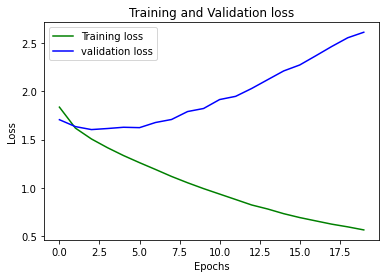

Test Accuracy = 41.870%
-----------------------------------------------


100%|██████████| 20/20 [06:26<00:00, 19.34s/it]


funct =  hardswish
lrate =  1e-05
train loss = 1.809335018634796 validation loss = 1.8260488011204778
validation accuracy= 6.434700012207031


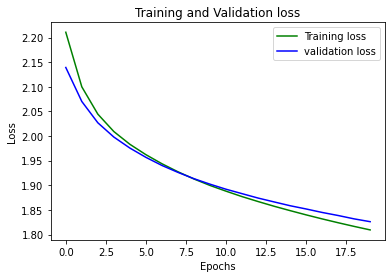

Test Accuracy = 36.390%
-----------------------------------------------


100%|██████████| 20/20 [06:26<00:00, 19.32s/it]


funct =  hardswish
lrate =  1e-07
train loss = 2.2633489555358888 validation loss = 2.2627823520392276
validation accuracy= 3.5690999031066895


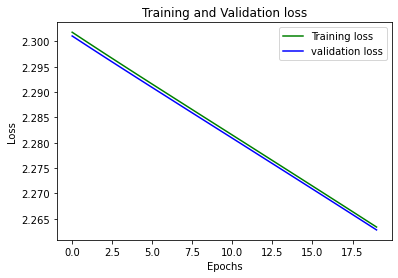

Test Accuracy = 19.860%
-----------------------------------------------


100%|██████████| 20/20 [06:24<00:00, 19.20s/it]


funct =  relu
lrate =  0.001
train loss = 0.5780274549841881 validation loss = 2.6114554028160657
validation accuracy= 8.59280014038086


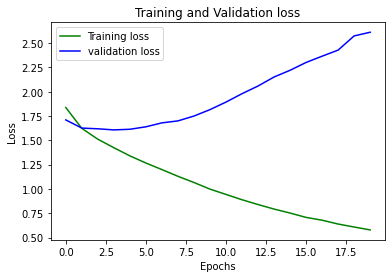

Test Accuracy = 41.760%
-----------------------------------------------


100%|██████████| 20/20 [06:24<00:00, 19.25s/it]


funct =  relu
lrate =  1e-05
train loss = 1.8040985798835754 validation loss = 1.8195207126605244
validation accuracy= 6.468800067901611


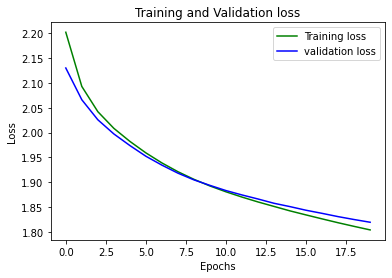

Test Accuracy = 36.590%
-----------------------------------------------


100%|██████████| 20/20 [06:25<00:00, 19.30s/it]


funct =  relu
lrate =  1e-07
train loss = 2.259596752166748 validation loss = 2.259058716198126
validation accuracy= 3.5556998252868652


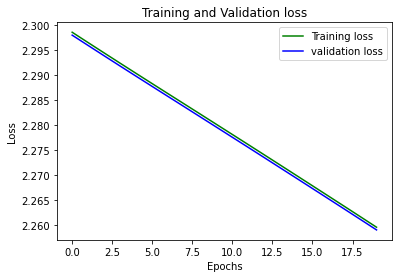

Test Accuracy = 21.490%
-----------------------------------------------


100%|██████████| 20/20 [06:23<00:00, 19.20s/it]

funct =  tanh
lrate =  0.001
train loss = 0.5758526614785194 validation loss = 2.7001906644802887
validation accuracy= 8.51140022277832


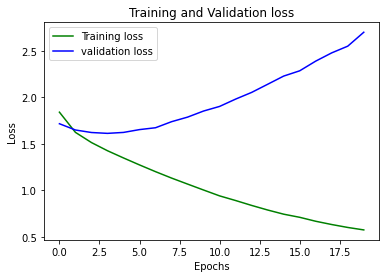

Test Accuracy = 42.020%
-----------------------------------------------


100%|██████████| 20/20 [06:27<00:00, 19.37s/it]


funct =  tanh
lrate =  1e-05
train loss = 1.8102526233673095 validation loss = 1.8254649475359688
validation accuracy= 6.405900001525879


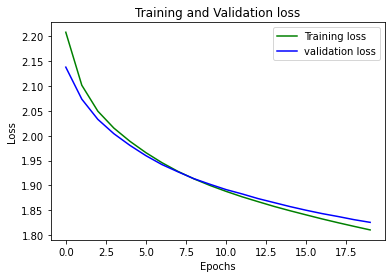

Test Accuracy = 36.320%
-----------------------------------------------


100%|██████████| 20/20 [06:25<00:00, 19.26s/it]


funct =  tanh
lrate =  1e-07
train loss = 2.264781170654297 validation loss = 2.2636555977903616
validation accuracy= 3.0727999210357666


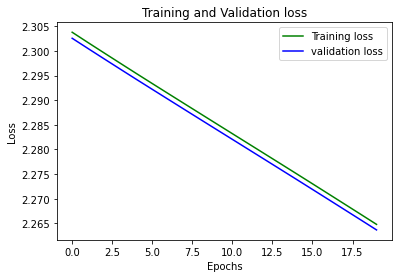

Test Accuracy = 18.330%
******************************
******************************


In [ ]:
layers = [1,2,3]
learning_rates = [1e-3, 1e-5, 1e-7]
activation_functions = ["hardswish", "relu", "tanh"]
results_list = [] # an entry can be like: [[3,1,2,loss,accuracy] (3 layers, 1st index LR, 2nd index F, loss, accuracy), [], [], ...]

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1 layer training
for func in activation_functions: #3 different act. functions
    for lrate in learning_rates: #3 different learning rates
        model = train_model1(lrate)
        test(model)

# 2 layer training
for func in activation_functions: #3 different act. functions
    for lrate in learning_rates: #3 different learning rates
        model = train_model2(lrate, func)
        test(model)

# 3 layer training
for func in activation_functions: #3 different act. functions
    for lrate in learning_rates: #3 different learning rates
        model = train_model3(lrate, func)
        test(model)

# checking out the best performing configurations
print("******************************")
# model = train_model1(1e-5)
# test(model)
# print("******************************")
# model = train_model2(1e-3, "relu")
# test(model)
# print("******************************")
# model = train_model3(1e-3, "relu")
# test(model)
print("******************************")